# Test Embedding Truncation

Durchführung eines Tests zur Prüfung der Auswirkungen der Kürzung der Embedding-Vektoren auf die Berechnung der Ähnlichkeit zwischen Texten mittels Vector-Similarity.

NV-Retriever: Improving text embedding models with effective hard-negative mining  
https://arxiv.org/pdf/2407.15831  
https://build.nvidia.com/nvidia/llama-nemotron-embed-1b-v2/modelcard#outputs

Matryoshka Representation Learning  
https://arxiv.org/pdf/2205.13147v4

**Voraussetzungen**

Environment: dski

**Test**

Das verwendete Embedding-Modell und die durch dieses erzeugten Embedding-Vektoren werden in verschiedenen Zusammenhängen wie der Berechung der Ähnlichkeit mittels Vector-Similarity zwischen den Modell- und Referenz-Antworten im Zuge der Evaluierung der Ausgabe der Sprachmodelle, der Indexierung der Kontext-Informationen im Vector-Store und deren Abfrage durch den Retriever sowie dem Training der Klassifikationsmodelle für die Segmentierung der Dokumente innerhalb der Untersuchungen verwendet.

Standardmäßig beträgt die Dimension der durch das Modell "nvidia/llama-nemotron-embed-1b-v2" erzeugten Embedding-Vektoren 2048.

Aufgrund des potentiell hohen Umfangs der daraus resultierenden Daten, welche im Vector-Store für das Retrieval indexiert sowie während des Trainings der Klassifikationsmodelle zur Segmentierung der Dokumente verarbeitet werden müssen und des eingeschränkten Umfangs der zur Verfügung stehenden Ressourcen (Speicher+Rechenleistung), soll zur Steigerung der Performance, speziell mit Blick auf die Optimierung der Modelle, eine Kürzung der Embedding-Vektoren durchgeführt und die Auswirkungen in einem Test geprüft werden.

Das Modell unterstützt Matryoshka-Embeddings, welche eine dynamische Anpassung der Länge der Embedding-Vektoren (384, 512, 768, 1024, 2048) ermöglichen. Bei Einsatz des Modells über vLLM wird die Verwendung der Matryoshka-Embeddings nicht direkt unterstützt (Fehlermeldung: Model "nvidia/llama-nemotron-embed-1b-v2" does not support matryoshka representation, changing output dimensions will lead to poor results.).

Aufgrund der verwendeten Matroschka-Repräsentationen sind die wichtigsten Informationen im vorderen Bereich des Vektors konzentriert, sodass eine Kürzung der Dimension ohne grundsätzlichen Informationsverlust möglich ist.

Für eine Stichprobe von 100 Dokumenten des open_ragbench-Datensatzes werden die Embedding-Vektoren für alle Abschnitte der gewählten Dokumente durch das Modell nvidia/llama-nemotron-embed-1b-v2 mit der vollen Dimension von 2048 erzeugt. Für einen Abschnitt und den jeweils darauf folgenden Abschnitt eines Dokuments wird die Ähnlichkeit der Embedding-Vektoren für die Dimensionen 384, 512, 768, 1024 und 2048 mit Hilfe des Dot-Product berechnet. Für die gewonnen Ähnlichkeitswerte wird anschließend die Differenz zwischen den Werten der Vektoren mit gekürzter Dimension und dem Vektor mit voller Dimension gebildet und die Ergebnisse miteinander verglichen.

## Setup

### Pakete laden

In [1]:
import config

import numpy as np
import pandas as pd

import pyarrow as pa
import pyarrow.parquet as pq

from openai import OpenAI

from plotly.subplots import make_subplots
import plotly.graph_objects as go

from util.datasetprocessor import DatasetProcessor
from util.pdfprocessor import PDFProcessor
from util.helper import Helper

In [2]:
# Anzahl Beobachtungen für Test
samples = 100

# OpenAI Client
openai_client_embedding = OpenAI(
    api_key=config.openai_client['api_key'],
    base_url=config.openai_client['embedding']['base_url']
)

### PDF-URLs laden

In [3]:
pdf_urls = pd.read_json(f'{config.dataset["path"]}pdf_urls_clean.json', orient='index', dtype_backend='numpy_nullable').rename(columns={0: 'pdf_urls'})

# Abgeglichene PDFs selektieren
pdf_urls = pdf_urls.loc[pdf_urls['pdf_urls'] == True]

# Stichprobe von 100 Dokumenten ziehen
pdf_urls = pdf_urls.sample(n=samples, axis=0, random_state=42)

## Test

Erzeugung der Embedding-Vektoren für Abschnitte und Berechnung der Ähnlichkeit mittels Cosine-Similarity zwischen einem Abschnitt und dessen folgenden Abschnitts mit voller Dimension und gekürzte Vektoren.

In [4]:
similarities = {'similarity_384':[], 'similarity_512':[], 'similarity_768':[], 'similarity_1024':[], 'similarity_2048':[]}#'similarity':[], 
#similarities = {'dimension':[], 'similarity':[]}

# Über alle Dokumente iterieren
for idx_doc in range(pdf_urls.shape[0]):
    doc_id = pdf_urls.iloc[idx_doc].name
    print(doc_id)

    # Dataframe mit vorverarbeiteten Daten laden
    df_doc_processed = pq.read_table(f'{config.dataset["path"]}pdfs_df/{doc_id}.parquet').to_pandas()
    
    # Embeddings für Blöcke des Dataframes erzeugen
    responses_embeddings = openai_client_embedding.embeddings.create(
        input=list(df_doc_processed['text'].str[:16384]),
        model=config.models['embedding'][0],
        #dimensions=512
    )

    # Über Embeddings iterieren
    for idx_block in range(len(responses_embeddings.data) - 1):
        # Cosine similarity für Dimensionen berechnen
        for d in [384, 512, 768, 1024, 2048]:
            # Cosine-Similarity für gekürztes Embedding zwischen aktuellem und folgendem Abschnitt berechnen
            # Verwendung der Cosine-Similarity da Vektoren nach Kürzung erneut normiert werden müssen
            similarities[f'similarity_{d}'].append(Helper.cosine_similarity(responses_embeddings.data[idx_block].embedding[:d], responses_embeddings.data[idx_block + 1].embedding[:d]))

2412.10128v2
2404.12556v2
2410.03930v3
2412.17526v1
2407.07009v2
2409.01111v2
2409.18804v2
2401.07152v3
2402.12350v3
2412.12448v2
2411.02807v4
2412.21038v2
2412.04468v2
2402.04429v3
2412.18501v3
2411.02767v2
2404.07128v3
2409.18582v2
2410.20812v3
2410.11095v2
2412.00566v2
2410.10364v2
2403.18980v3
2405.06851v2
2412.17780v3
2402.10674v2
2404.02595v3
2404.17994v2
2406.07641v2
2405.18220v2
2408.05109v4
2408.09208v2
2404.14603v2
2406.10332v2
2412.00886v2
2410.05967v2
2409.00095v1
2409.13260v2
2407.00037v2
2408.11115v2
2409.15511v2
2411.11032v2
2409.08951v2
2408.16245v3
2411.09216v2
2411.03217v2
2412.13892v2
2410.00332v5
2410.14587v1
2412.04042v3
2403.05038v3
2410.16563v1
2401.08843v2
2411.00434v2
2410.17011v3
2402.00252v3
2410.00908v2
2410.22568v1
2408.09876v2
2412.20570v1
2409.17606v2
2411.13383v2
2410.20081v3
2405.20880v2
2411.12860v4
2409.16681v2
2410.20476v2
2410.16169v1
2405.20769v2
2405.06385v2
2403.04102v2
2402.09444v3
2408.07618v3
2411.06721v2
2406.02319v2
2408.10293v2
2406.01398v4

### Stats

In [11]:
# Dataframe aus Dict metric erzeugen
df_similarities = pd.DataFrame.from_dict(similarities)

In [12]:
# Differenz der Ähnlichkeit für gekürzte Embeddings gegenüber voller Dimension berechnen
for d in [384, 512, 768, 1024]:
    df_similarities[f'similarity_{d}_diff'] = (df_similarities[f'similarity_{d}'] - df_similarities['similarity_2048']).abs()

In [13]:
# Statistische Kennzahlen für Werte berechnen
df_similarities.describe()

,similarity_384,similarity_512,similarity_768,similarity_1024,similarity_2048,similarity_384_diff,similarity_512_diff,similarity_768_diff,similarity_1024_diff
count,31424.000000,31424.000000,31424.000000,31424.000000,31424.000000,3.142400e+04,3.142400e+04,3.142400e+04,3.142400e+04
mean,0.402011,0.393826,0.395796,0.405949,0.409886,3.153564e-02,3.020244e-02,2.343777e-02,1.438418e-02
std,0.185082,0.184509,0.184386,0.184970,0.184459,2.511081e-02,2.342936e-02,1.815048e-02,1.143503e-02
min,-0.093443,-0.080996,-0.065673,-0.058004,-0.045056,7.771561e-15,5.329071e-15,2.331468e-15,5.662137e-15
25%,0.265896,0.258306,0.260963,0.270768,0.275294,1.188773e-02,1.164803e-02,9.018894e-03,5.400520e-03
50%,0.391830,0.382107,0.384324,0.396588,0.400808,2.565588e-02,2.510983e-02,1.945858e-02,1.179292e-02
75%,0.523569,0.514031,0.516057,0.528024,0.531900,4.541649e-02,4.361748e-02,3.393741e-02,2.065166e-02
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.838613e-01,1.780103e-01,1.238444e-01,9.038282e-02


| | similarity_384 | similarity_512 | similarity_768 | similarity_1024 | similarity_2048 |
| - | - | - | - | - | - |
| mean | 0.402011 | 0.393826 | 0.395796 | 0.405949 | 0.409886 |
| std | 0.185082 | 0.184509 | 0.184386 | 0.184970 | 0.184459 |
| min | -0.093443 | -0.080996 | -0.065673 | -0.058004 | -0.045056 |
| 25% | 0.265896 | 0.258306 | 0.260963 | 0.270768 | 0.275294 |
| 50% | 0.391830 | 0.382107 | 0.384324 | 0.396588 | 0.400808 |
| 75% | 0.523569 | 0.514031 | 0.516057 | 0.528024 | 0.531900 |
| max | 1.000000 | 1.000000 | 1.000000 | 1.000000 | 1.000000 |

Die mit Hilfe des Cosine-Similarity berechneten Ähnlichkeiten zwischen den Text-Embeddings der Abschnitte mit voller Dimension von 2048 beträgt im Durchschnitt ca. 0.4099 und verringern sich für die Dimension 384 lediglich geringfügig auf 0.402.

| | similarity_384_diff | similarity_512_diff | similarity_768_diff | similarity_1024_diff |
| - | - | - | - | - |
| mean | 3.153564e-02 | 3.020244e-02 | 2.343777e-02 | 1.438418e-02 |
| std | 2.511081e-02 | 2.342936e-02 | 1.815048e-02 | 1.143503e-02 |
| min | 7.771561e-15 | 5.329071e-15 | 2.331468e-15 | 5.662137e-15 |
| 25% | 1.188773e-02 | 1.164803e-02 | 9.018894e-03 | 5.400520e-03 |
| 50% | 2.565588e-02 | 2.510983e-02 | 1.945858e-02 | 1.179292e-02 |
| 75% | 4.541649e-02 | 4.361748e-02 | 3.393741e-02 | 2.065166e-02 |
| max | 1.838613e-01 | 1.780103e-01 | 1.238444e-01 | 9.038282e-02 |

Die durchschnittliche Differenz sowie Standardabweichung der Ähnlichkeiten zwischen den gekürzten und vollständigen Vektoren steigt mit Reduzierung der Dimension und beträgt zwischen 1024 und 384 mehr als das Zweifache, führt insgesamt aber zu einer eher geringen Verringerung der Genauigkeit.

Im Zusammenhang mit der Indexierung der Dokumente für das Retrieval im Vector-Store sowie dem Training der Klassifikationsmodelle zur Segmentierung der Dokumente werden weitere Tests zur Kürzung der Vektoren durchgeführt und an dieser Stelle keine Auswahl getroffen. Für die Berechnung der Ähnlichkeit der Embedding-Vektoren mittels Vector-Similarity während der Evaluierung wird aufgrund des geringen Speicher- und Rechenbedarfs die vollständige Dimension von 2048 verwendet.

### Box-Plot Ähnlichkeiten Differenzen

Darstellung der Differenzen der Ähnlichkeiten zwischen gekürzten und vollständigen Embedding-Vektoren als Box-Plot.

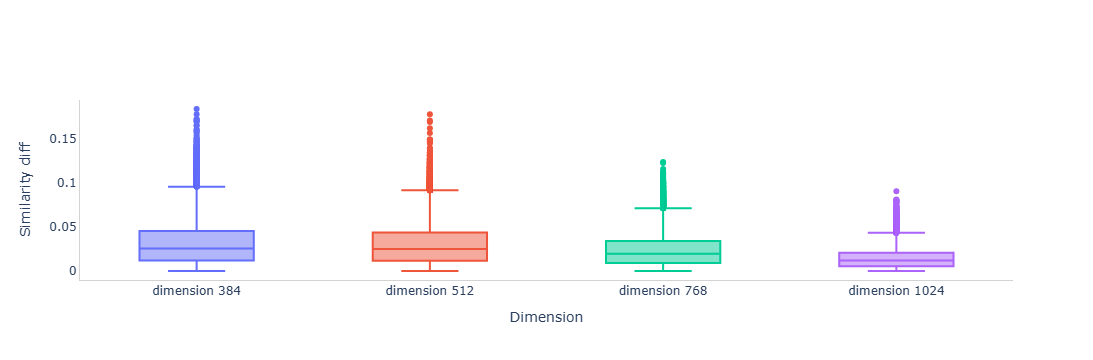

In [8]:
# Box plot Differenz der Cosine similarity für unterschiedliche Dimensionen
fig = go.Figure()

for d in [384, 512, 768, 1024]:
    fig.add_trace(go.Box(
        y=df_similarities[f'similarity_{d}_diff'],
        name=f'dimension {d}'
    ))
    
fig.update_yaxes(showgrid=False, showline=True, linewidth=1, linecolor='LightGrey', title='Similarity diff')
fig.update_xaxes(showline=True, linewidth=1, linecolor='LightGrey', title='Dimension')

fig.update_layout(plot_bgcolor='rgba(0, 0, 0, 0)', 
                  paper_bgcolor='rgba(0, 0, 0, 0)', 
                  #margin={'l':0, 'b':0, 'r':0, 't':0},
                  showlegend=False)#

fig.show()

In [14]:
print(df_similarities.loc[df_similarities['similarity_512_diff'].nlargest(5).index])#idxmax()

       similarity_384  similarity_512  similarity_768  similarity_1024  \
6906         0.028578        0.021305        0.090391         0.135310   
7037         0.021947        0.015992        0.084917         0.125296   
31285        0.061678        0.033670        0.114981         0.155085   
27776        0.310855        0.244410        0.282501         0.350854   
7788         0.125860        0.118561        0.190962         0.244185   

       similarity_2048  similarity_384_diff  similarity_512_diff  \
6906          0.199315             0.170736             0.178010   
7037          0.186833             0.164886             0.170841   
31285         0.202643             0.140965             0.168972   
27776         0.406345             0.095491             0.161935   
7788          0.275272             0.149412             0.156711   

       similarity_768_diff  similarity_1024_diff  
6906              0.108924              0.064005  
7037              0.101917              0.06